In [ ]:
import sympy as sp
import matplotlib.pyplot as plt
from control.matlab import tf, step, pzmap, poles, zeros
import numpy as np

In [3]:
# 1. Make symbols
s = sp.symbols('s')
U = sp.symbols('U')
V = sp.symbols('V')

# 2. Write the equation: 2*s^2*V + s*V = s*U + U
left = 2*s**2 * V + s * V
right = s * U + U

In [15]:
# 3. Get V/U transfer function
G = sp.solve(sp.Eq(left, right), V)[0] / U
G_simple = sp.simplify(G)

print(f"Transfer Function G(s): {G_simple}")

# 4. Make it for control library
num = [float(c) for c in sp.Poly(sp.numer(G_simple), s).all_coeffs()]
den = [float(c) for c in sp.Poly(sp.denom(G_simple), s).all_coeffs()]

system = tf(num, den)
print(system)


Transfer Function G(s): (s + 1)/(s*(2*s + 1))
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [16]:
# 5. Show poles and zeros
print(f"Poles: {pole(system)}")
print(f"Zeros: {zeros(system)}")

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


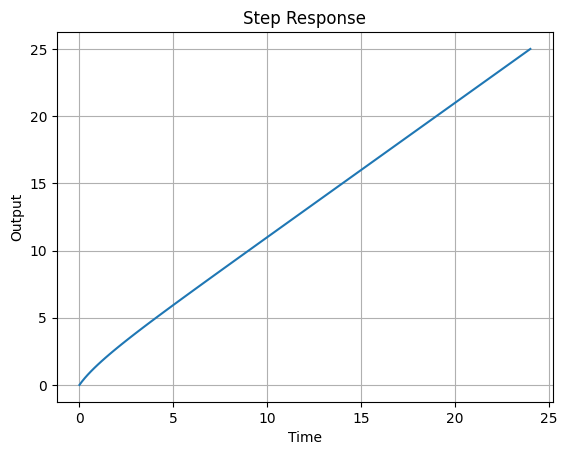

In [19]:
# 6. Step response plot
t_vec, y_out = step(system)
plt.plot(t_vec, y_out)
plt.title('Step Response')
plt.xlabel('Time')
plt.ylabel('Output')
plt.grid(True)
plt.show()

C:\Users\Benize\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\control\pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


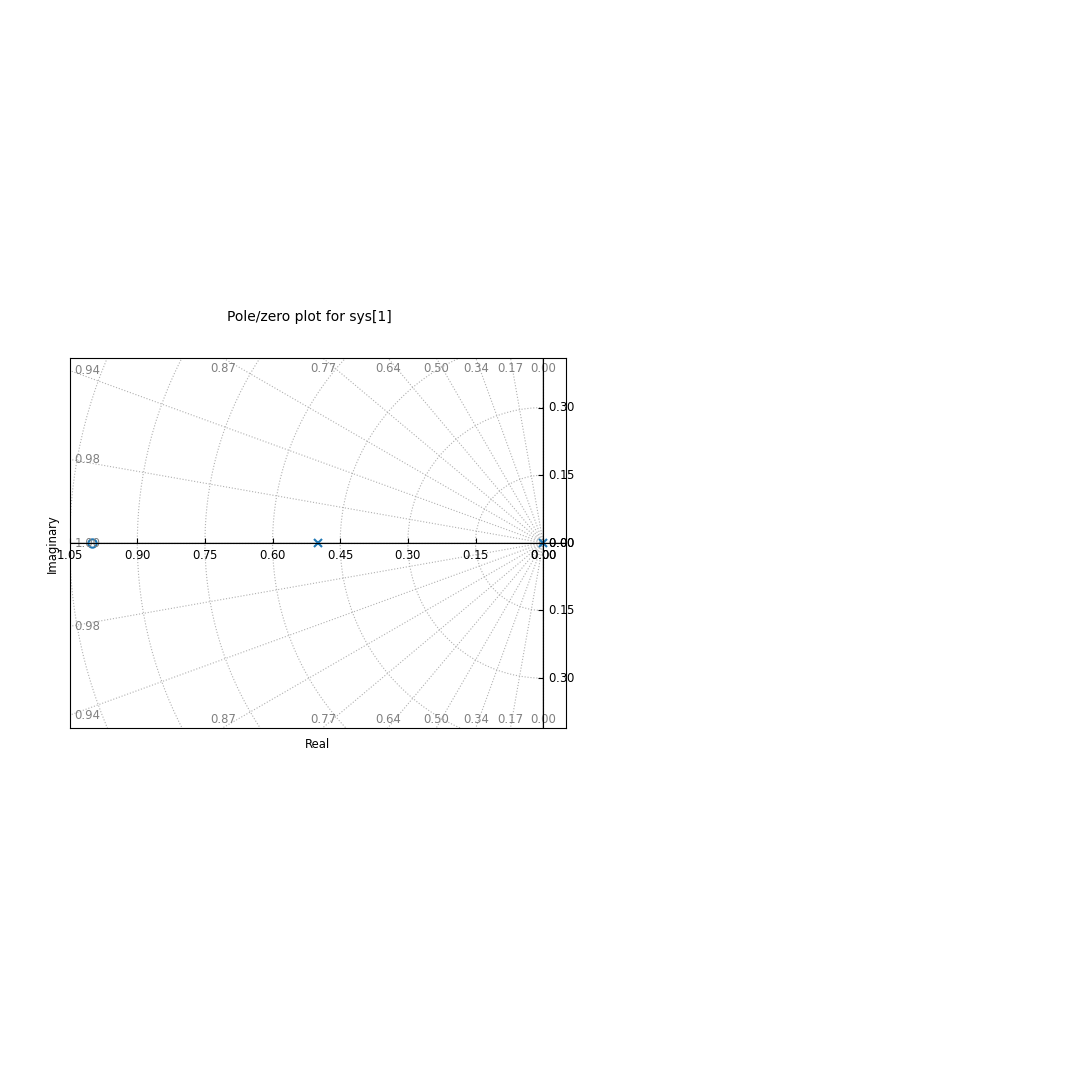

In [25]:
# 7. Pole zero plot
pzmap(system, grid=True)
plt.show()